### Raw-location duplicate check (pre-registration)
This reports exact duplicate electrode coordinates from raw `*_xslocs.mat` files before MNI registration.


In [5]:
from pathlib import Path  # Import Path for readable filesystem paths
import numpy as np  # Import NumPy for loading arrays and duplicate detection

in_dir = Path('/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs')  # Folder with original registered electrode files
out_dir = Path('/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates')  # Folder where cleaned files will be saved
out_dir.mkdir(parents=True, exist_ok=True)  # Create output folder if it does not already exist

for f in sorted(in_dir.glob('*_xslocs_registered_mm.npy')):  # Loop through each subject file in a stable sorted order
    pid = f.stem.split('_')[0]  # Extract subject label from filename (e.g., 'aa' from 'aa_xslocs_registered_mm.npy')
    locs = np.load(f).astype(np.float32).reshape(-1, 3)  # Load coordinates and force shape to (num_electrodes, 3)

    _, inv, counts = np.unique(locs, axis=0, return_inverse=True, return_counts=True)  # Find unique coordinates and how often each appears
    keep_mask = counts[inv] == 1  # Mark electrodes to keep (only coordinates that appear exactly once)
    clean_locs = locs[keep_mask]  # Keep only non-duplicated electrode coordinates

    out_file = out_dir / f'{pid}_xslocs_registered_no_dups.npy'  # Build output filename for this subject
    np.save(out_file, clean_locs)  # Save cleaned coordinates to the no-duplicates folder

    removed = int((~keep_mask).sum())  # Count how many electrodes were removed (all duplicate copies)
    print(f'[{pid}] in={len(locs)} out={len(clean_locs)} removed={removed} -> {out_file.name}', flush=True)  # Print per-subject summary line

print('Done.', flush=True)  # Print final completion message after all subjects are processed


[aa] in=46 out=46 removed=0 -> aa_xslocs_registered_no_dups.npy
[ap] in=41 out=41 removed=0 -> ap_xslocs_registered_no_dups.npy
[ca] in=50 out=48 removed=2 -> ca_xslocs_registered_no_dups.npy
[de] in=31 out=31 removed=0 -> de_xslocs_registered_no_dups.npy
[fp] in=52 out=10 removed=42 -> fp_xslocs_registered_no_dups.npy
[ha] in=39 out=39 removed=0 -> ha_xslocs_registered_no_dups.npy
[ja] in=60 out=37 removed=23 -> ja_xslocs_registered_no_dups.npy
[jm] in=56 out=24 removed=32 -> jm_xslocs_registered_no_dups.npy
[jt] in=102 out=96 removed=6 -> jt_xslocs_registered_no_dups.npy
[mv] in=58 out=18 removed=40 -> mv_xslocs_registered_no_dups.npy
[rn] in=42 out=40 removed=2 -> rn_xslocs_registered_no_dups.npy
[rr] in=40 out=40 removed=0 -> rr_xslocs_registered_no_dups.npy
[wc] in=39 out=39 removed=0 -> wc_xslocs_registered_no_dups.npy
[zt] in=58 out=58 removed=0 -> zt_xslocs_registered_no_dups.npy
Done.


In [6]:
from pathlib import Path  # Import Path for readable input/output paths
import numpy as np  # Import NumPy for array loading and duplicate filtering

in_file = Path('/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/all_electrodes_mni_locs.npy')  # Input pooled electrode coordinates
out_file = Path('/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/all_electrodes_mni_locs_no_dups.npy')  # Output file after removing all duplicates

locs = np.load(in_file).astype(np.float32).reshape(-1, 3)  # Load pooled coordinates as (N, 3)

_, inv, counts = np.unique(locs, axis=0, return_inverse=True, return_counts=True)  # Count repeats for each coordinate
keep_mask = counts[inv] == 1  # Keep only coordinates that appear exactly once
clean_locs = locs[keep_mask]  # Remove every member of each duplicate coordinate group

np.save(out_file, clean_locs)  # Save cleaned pooled coordinates

removed = int((~keep_mask).sum())  # Number of removed rows (all duplicate copies)
print(f'Pooled electrodes: in={len(locs)} out={len(clean_locs)} removed={removed} -> {out_file}')  # Print summary


Pooled electrodes: in=714 out=567 removed=147 -> /Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/all_electrodes_mni_locs_no_dups.npy


In [7]:
from pathlib import Path
import numpy as np

in_dir = Path('/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs')

for subject_num, f in enumerate(sorted(in_dir.glob('*_xslocs_registered_mm.npy')), start=1):
    locs = np.load(f).astype(np.float32).reshape(-1, 3)

    _, inv, counts = np.unique(locs, axis=0, return_inverse=True, return_counts=True)
    keep_mask = counts[inv] == 1
    removed_idx = np.where(~keep_mask)[0]

    print(f'Subject {subject_num}: removed_indices={removed_idx.tolist()} (n={len(removed_idx)})')


Subject 1: removed_indices=[] (n=0)
Subject 2: removed_indices=[] (n=0)
Subject 3: removed_indices=[0, 18] (n=2)
Subject 4: removed_indices=[] (n=0)
Subject 5: removed_indices=[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51] (n=42)
Subject 6: removed_indices=[] (n=0)
Subject 7: removed_indices=[37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59] (n=23)
Subject 8: removed_indices=[24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55] (n=32)
Subject 9: removed_indices=[64, 65, 66, 67, 68, 69] (n=6)
Subject 10: removed_indices=[18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57] (n=40)
Subject 11: removed_indices=[3, 6] (n=2)
Subject 12: removed_indices

In [8]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat


In [9]:
# Each subjets electrode locations, registered to MNI space, in mm
aa_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/aa_xslocs_registered_no_dups.npy")
ap_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/ap_xslocs_registered_no_dups.npy")
ca_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/ca_xslocs_registered_no_dups.npy")
de_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/de_xslocs_registered_no_dups.npy")
fp_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/fp_xslocs_registered_no_dups.npy")
ha_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/ha_xslocs_registered_no_dups.npy")
ja_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/ja_xslocs_registered_no_dups.npy")
jm_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/jm_xslocs_registered_no_dups.npy")
jt_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/jt_xslocs_registered_no_dups.npy")
mv_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/mv_xslocs_registered_no_dups.npy")
rn_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/rn_xslocs_registered_no_dups.npy")
rr_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/rr_xslocs_registered_no_dups.npy")
wc_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/wc_xslocs_registered_no_dups.npy")
zt_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates/zt_xslocs_registered_no_dups.npy")


In [10]:
# All subjects' electrode locations in mni

all_electrodes = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/all_electrodes_mni_locs_no_dups.npy")


In [11]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat
from scipy import signal, stats

project_root = Path('/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project')
registered_dir = project_root / 'registered_outputs_no_duplicates'
data_root = Path('/Users/rustin/Documents/Big Data 567/faces_basic/data')
out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
out_dir.mkdir(parents=True, exist_ok=True)

srate = 1000  # Hz
sos_notch = signal.butter(4, [59.5, 60.5], btype='bandstop', fs=srate, output='sos')
kurtosis_thresh = 10  # drop channels with kurtosis >= 10 (same as SuperEEG paper)

print(f'Registered locs dir: {registered_dir}')
print(f'ECoG data dir:      {data_root}')
print(f'Per-subject output: {out_dir}')


Registered locs dir: /Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs_no_duplicates
ECoG data dir:      /Users/rustin/Documents/Big Data 567/faces_basic/data
Per-subject output: /Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed


### Step 1: Import kurtosis helper
Use SciPy kurtosis with default behavior (matches `supereeg`: `fisher=True`, `bias=True`).


In [12]:
from scipy.stats import kurtosis


### Step 2: Gather registered electrode-location files
These drive subject-by-subject preprocessing.


In [13]:
subject_loc_files = sorted(registered_dir.glob('*_xslocs_registered_no_dups.npy'))
print(f'Found {len(subject_loc_files)} registered location files')


Found 14 registered location files


### Step 3: Per-subject preprocessing function


In [14]:
def preprocess_subject(npy_file):
    pid = npy_file.stem.split('_')[0]
    locs = np.load(npy_file).astype(np.float32, copy=False)
    mat_path = data_root / pid / f'{pid}_faceshouses.mat'
    if not mat_path.exists():
        print(f'[{pid}] missing ECoG file: {mat_path}')
        return
    mat = loadmat(mat_path, squeeze_me=True)
    ecog = np.asarray(mat['data'], dtype=np.float32)
    if ecog.ndim != 2:
        print(f'[{pid}] expected 2D ecog array, got shape {ecog.shape}; skipped')
        return
    if ecog.shape[1] != locs.shape[0]:
        keep_idx_path = registered_dir / f'{pid}_xslocs_registered_no_dups_keep_idx.npy'
        if keep_idx_path.exists():
            keep_idx = np.load(keep_idx_path).astype(int)
            if keep_idx.size == locs.shape[0] and np.max(keep_idx, initial=-1) < ecog.shape[1]:
                ecog = ecog[:, keep_idx]
                print(f'[{pid}] applied keep_idx from {keep_idx_path.name}; ecog channels now {ecog.shape[1]}')
            else:
                print(f'[{pid}] invalid keep_idx in {keep_idx_path.name}; skipped')
                return
        else:
            print(f'[{pid}] channel/loc mismatch: ecog channels={ecog.shape[1]} vs locs={locs.shape[0]}; skipped')
            return
    stim = mat.get('stim')
    if stim is not None:
        stim = np.asarray(stim).ravel()
        if stim.shape[0] != ecog.shape[0]:
            print(f'[{pid}] stim length mismatch ({stim.shape[0]}) vs ecog rows ({ecog.shape[0]}); using all samples')
            ecog_nz = ecog
        else:
            mask = stim != 0
            ecog_nz = ecog[mask]
            if ecog_nz.shape[0] == 0:
                print(f'[{pid}] no non-zero stimulus samples; skipped')
                return
    else:
        ecog_nz = ecog
    filtered_ecog = signal.sosfiltfilt(sos_notch, ecog_nz, axis=0).astype(np.float32, copy=False)
    # Match supereeg default kurtosis behavior (SciPy defaults: fisher=True, bias=True)
    k = kurtosis(filtered_ecog, axis=0)
    good_idx = np.where(k <= kurtosis_thresh)[0]
    if good_idx.size < 2:
        print(f'[{pid}] only {good_idx.size} channels after kurtosis filter; skipped')
        return
    cleaned_ecog = filtered_ecog[:, good_idx]
    cleaned_locs = locs[good_idx]
    out_path = out_dir / f'{pid}_preprocessed.npz'
    np.savez_compressed(
        out_path,
        subject_id=np.array(pid),
        sample_rate_hz=np.int32(srate),
        locs_mni_mm=cleaned_locs,
        ecog=cleaned_ecog,
    )
    dropped = locs.shape[0] - good_idx.size
    print(f'[{pid}] kept {good_idx.size}/{locs.shape[0]} channels (dropped {dropped} with kurtosis>{kurtosis_thresh})')
    print(f'[{pid}] wrote {out_path.name} | ecog={cleaned_ecog.shape}, locs={cleaned_locs.shape}')


### Step 4: Run preprocessing for all subjects


In [15]:
for npy_file in subject_loc_files:
    preprocess_subject(npy_file)


[aa] kept 41/46 channels (dropped 5 with kurtosis>10)
[aa] wrote aa_preprocessed.npz | ecog=(244200, 41), locs=(41, 3)
[ap] kept 40/41 channels (dropped 1 with kurtosis>10)
[ap] wrote ap_preprocessed.npz | ecog=(241200, 40), locs=(40, 3)
[ca] invalid keep_idx in ca_xslocs_registered_no_dups_keep_idx.npy; skipped
[de] kept 31/31 channels (dropped 0 with kurtosis>10)
[de] wrote de_preprocessed.npz | ecog=(244200, 31), locs=(31, 3)
[fp] invalid keep_idx in fp_xslocs_registered_no_dups_keep_idx.npy; skipped
[ha] kept 39/39 channels (dropped 0 with kurtosis>10)
[ha] wrote ha_preprocessed.npz | ecog=(242200, 39), locs=(39, 3)
[ja] invalid keep_idx in ja_xslocs_registered_no_dups_keep_idx.npy; skipped
[jm] invalid keep_idx in jm_xslocs_registered_no_dups_keep_idx.npy; skipped
[jt] invalid keep_idx in jt_xslocs_registered_no_dups_keep_idx.npy; skipped
[mv] invalid keep_idx in mv_xslocs_registered_no_dups_keep_idx.npy; skipped
[rn] invalid keep_idx in rn_xslocs_registered_no_dups_keep_idx.npy; 

# Quick look at first subject (`*_preprocessed.npz`: locs + ecog, no stim file)

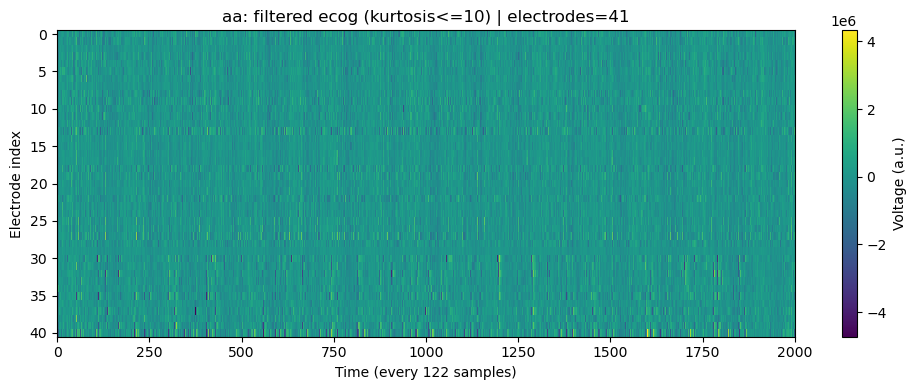

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
subject_files = sorted(out_dir.glob('*_preprocessed.npz'))
if not subject_files:
    raise FileNotFoundError('No *_preprocessed.npz files found in output dir')

first_path = subject_files[0]
pack = np.load(first_path, allow_pickle=True)
pid = str(pack['subject_id'].item())
ecog = pack['ecog']
locs = pack['locs_mni_mm']

step = max(1, ecog.shape[0] // 2000)
ecog_ds = ecog[::step]

plt.figure(figsize=(10, 4))
im = plt.imshow(ecog_ds.T, aspect='auto', cmap='viridis', interpolation='nearest')
plt.colorbar(im, label='Voltage (a.u.)')
plt.xlabel(f'Time (every {step} samples)')
plt.ylabel('Electrode index')
plt.title(f'{pid}: filtered ecog (kurtosis<={kurtosis_thresh}) | electrodes={locs.shape[0]}')
plt.tight_layout()
plt.show()


In [17]:
from pathlib import Path
import numpy as np

out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
subject_files = sorted(out_dir.glob('*_preprocessed.npz'))
if not subject_files:
    raise FileNotFoundError('No *_preprocessed.npz files found in output dir')

path = subject_files[0]
pack = np.load(path, allow_pickle=True)

print(f'File: {path.name}')
print('Keys:', pack.files)
print('subject_id:', pack['subject_id'].item())
print('sample_rate_hz:', int(pack['sample_rate_hz']))
print('locs_mni_mm shape:', pack['locs_mni_mm'].shape)
print('ecog shape:', pack['ecog'].shape)


File: aa_preprocessed.npz
Keys: ['subject_id', 'sample_rate_hz', 'locs_mni_mm', 'ecog']
subject_id: aa
sample_rate_hz: 1000
locs_mni_mm shape: (41, 3)
ecog shape: (244200, 41)


# Optional: combine all per-subject `*_preprocessed.npz` files into one object array

In [18]:
# Run after per-subject files exist
from pathlib import Path
import numpy as np

out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
records = []

for sub_path in sorted(out_dir.glob('*_preprocessed.npz')):
    pack = np.load(sub_path, allow_pickle=True)
    records.append({
        'patient_id': str(pack['subject_id'].item()),
        'sample_rate_hz': int(pack['sample_rate_hz']),
        'locs_mni_mm': pack['locs_mni_mm'],
        'ecog': pack['ecog'],
    })

combined_path = out_dir / 'all_locs_mni_and_ecog_preprocessed.npy'
np.save(combined_path, np.array(records, dtype=object))
print(f'Combined {len(records)} patients to {combined_path}')


Combined 13 patients to /Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed/all_locs_mni_and_ecog_preprocessed.npy


In [19]:
import numpy as np

path = "/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed/all_locs_mni_and_ecog_preprocessed.npy"
all_locs = np.load(path, allow_pickle=True)

print(all_locs.shape)
print(all_locs[0].keys())  # patient_id, sample_rate_hz, locs_mni_mm, ecog


(13,)
dict_keys(['patient_id', 'sample_rate_hz', 'locs_mni_mm', 'ecog'])


# Convert each per-subject preprocessed file to SuperEEG `file_io` input format


In [20]:
from pathlib import Path
import numpy as np

preprocessed_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
npz_out_dir = Path('/Users/rustin/Documents/Big Data 567/Faces_Basic_npz_for_supereeg')
npz_out_dir.mkdir(parents=True, exist_ok=True)

for sub_path in sorted(preprocessed_dir.glob('*_preprocessed.npz')):
    pack = np.load(sub_path, allow_pickle=True)

    pid = str(pack['subject_id'].item())
    Y = pack['ecog']                                   # (time, channels)
    R = pack['locs_mni_mm']                            # (channels, 3) MNI mm
    samplerate   = np.array([int(pack['sample_rate_hz'])])  # 1-D, one value per session
    fname_labels = np.array([pid])                     # one session label

    out_path = npz_out_dir / f'{pid}.npz'
    np.savez(out_path, Y=Y, R=R, samplerate=samplerate, fname_labels=fname_labels)
    print(f'[{pid}] Y={Y.shape} R={R.shape} samplerate={samplerate} -> {out_path.name}')

print('Done.')


[aa] Y=(244200, 41) R=(41, 3) samplerate=[1000] -> aa.npz
[ap] Y=(241200, 40) R=(40, 3) samplerate=[1000] -> ap.npz
[ca] Y=(244200, 49) R=(49, 3) samplerate=[1000] -> ca.npz
[de] Y=(244200, 31) R=(31, 3) samplerate=[1000] -> de.npz
[fp] Y=(244200, 11) R=(11, 3) samplerate=[1000] -> fp.npz
[ha] Y=(242200, 39) R=(39, 3) samplerate=[1000] -> ha.npz
[ja] Y=(244200, 37) R=(37, 3) samplerate=[1000] -> ja.npz
[jt] Y=(244200, 96) R=(96, 3) samplerate=[1000] -> jt.npz
[mv] Y=(244200, 19) R=(19, 3) samplerate=[1000] -> mv.npz
[rn] Y=(244240, 41) R=(41, 3) samplerate=[1000] -> rn.npz
[rr] Y=(162800, 40) R=(40, 3) samplerate=[1000] -> rr.npz
[wc] Y=(244200, 38) R=(38, 3) samplerate=[1000] -> wc.npz
[zt] Y=(244200, 58) R=(58, 3) samplerate=[1000] -> zt.npz
Done.


###### Check: Subject Lengths + Stimulus Order Across Subjects

This section replaces ad-hoc stimulus checks from `ECoG-2.ipynb` with one shared preprocessing check.


In [21]:
# Load each subject's raw stim vector from faces_basic/data/<pid>/<pid>_faceshouses.mat
from pathlib import Path
import numpy as np
from scipy.io import loadmat

raw_data_root = Path('/Users/rustin/Documents/Big Data 567/faces_basic/data')

stim_by_subject = {}
length_rows = []

for subj_dir in sorted(raw_data_root.iterdir()):
    if not subj_dir.is_dir():
        continue
    pid = subj_dir.name
    mat_path = subj_dir / f'{pid}_faceshouses.mat'
    if not mat_path.exists():
        continue

    mat = loadmat(mat_path, squeeze_me=True)
    if 'stim' not in mat:
        print(f'[{pid}] missing stim in {mat_path.name}')
        continue

    stim = np.asarray(mat['stim']).ravel()
    stim_by_subject[pid] = stim

    data_len = int(np.asarray(mat['data']).shape[0]) if 'data' in mat else -1
    length_rows.append((pid, stim.shape[0], data_len))

print('Loaded stim for', len(stim_by_subject), 'subjects')
print('')
print('Length summary (stim_len vs data_len):')
for pid, stim_len, data_len in length_rows:
    flag = '' if stim_len == data_len else '  <-- mismatch'
    print(f'  {pid}: stim={stim_len}, data={data_len}{flag}')


Loaded stim for 14 subjects

Length summary (stim_len vs data_len):
  aa: stim=271400, data=271400
  ap: stim=268400, data=268400
  ca: stim=271360, data=271360
  de: stim=271400, data=271400
  fp: stim=271400, data=271400
  ha: stim=251240, data=251240
  ja: stim=271400, data=271400
  jm: stim=271440, data=271440
  jt: stim=271400, data=271400
  mv: stim=271400, data=271400
  rn: stim=271440, data=271440
  rr: stim=180920, data=180920
  wc: stim=271400, data=271400
  zt: stim=271400, data=271400


In [22]:
# Check whether non-zero event order matches a reference subject.
# We collapse repeated runs so we compare event order, not duration.

def collapse_event_order(stim):
    stim = np.asarray(stim).ravel()
    nz = stim[stim != 0]
    if nz.size == 0:
        return np.array([], dtype=nz.dtype)
    keep = np.r_[True, nz[1:] != nz[:-1]]
    return nz[keep]

if 'aa' in stim_by_subject:
    ref_pid = 'aa'
else:
    ref_pid = sorted(stim_by_subject.keys())[0]

ref_seq = collapse_event_order(stim_by_subject[ref_pid])
print('Reference subject:', ref_pid)
print('Reference event-order length:', len(ref_seq))
print('Reference first 30 events:', ref_seq[:30].astype(int).tolist())
print('')

print('Event-order comparison to reference:')
for pid in sorted(stim_by_subject.keys()):
    seq = collapse_event_order(stim_by_subject[pid])
    same_full = np.array_equal(seq, ref_seq)

    # prefix check helps when one subject is shorter
    m = min(len(seq), len(ref_seq))
    same_prefix = np.array_equal(seq[:m], ref_seq[:m])

    print(f'  {pid}: events={len(seq)} | same_full={same_full} | same_prefix={same_prefix}')


Reference subject: aa
Reference event-order length: 601
Reference first 30 events: [101, 11, 101, 51, 101, 94, 101, 84, 101, 7, 101, 97, 101, 21, 101, 81, 101, 36, 101, 38, 101, 56, 101, 15, 101, 47, 101, 65, 101, 17]

Event-order comparison to reference:
  aa: events=601 | same_full=True | same_prefix=True
  ap: events=601 | same_full=True | same_prefix=True
  ca: events=601 | same_full=True | same_prefix=True
  de: events=601 | same_full=True | same_prefix=True
  fp: events=601 | same_full=True | same_prefix=True
  ha: events=601 | same_full=True | same_prefix=True
  ja: events=601 | same_full=True | same_prefix=True
  jm: events=601 | same_full=True | same_prefix=True
  jt: events=601 | same_full=True | same_prefix=True
  mv: events=601 | same_full=True | same_prefix=True
  rn: events=601 | same_full=True | same_prefix=True
  rr: events=401 | same_full=False | same_prefix=True
  wc: events=601 | same_full=True | same_prefix=True
  zt: events=601 | same_full=True | same_prefix=True


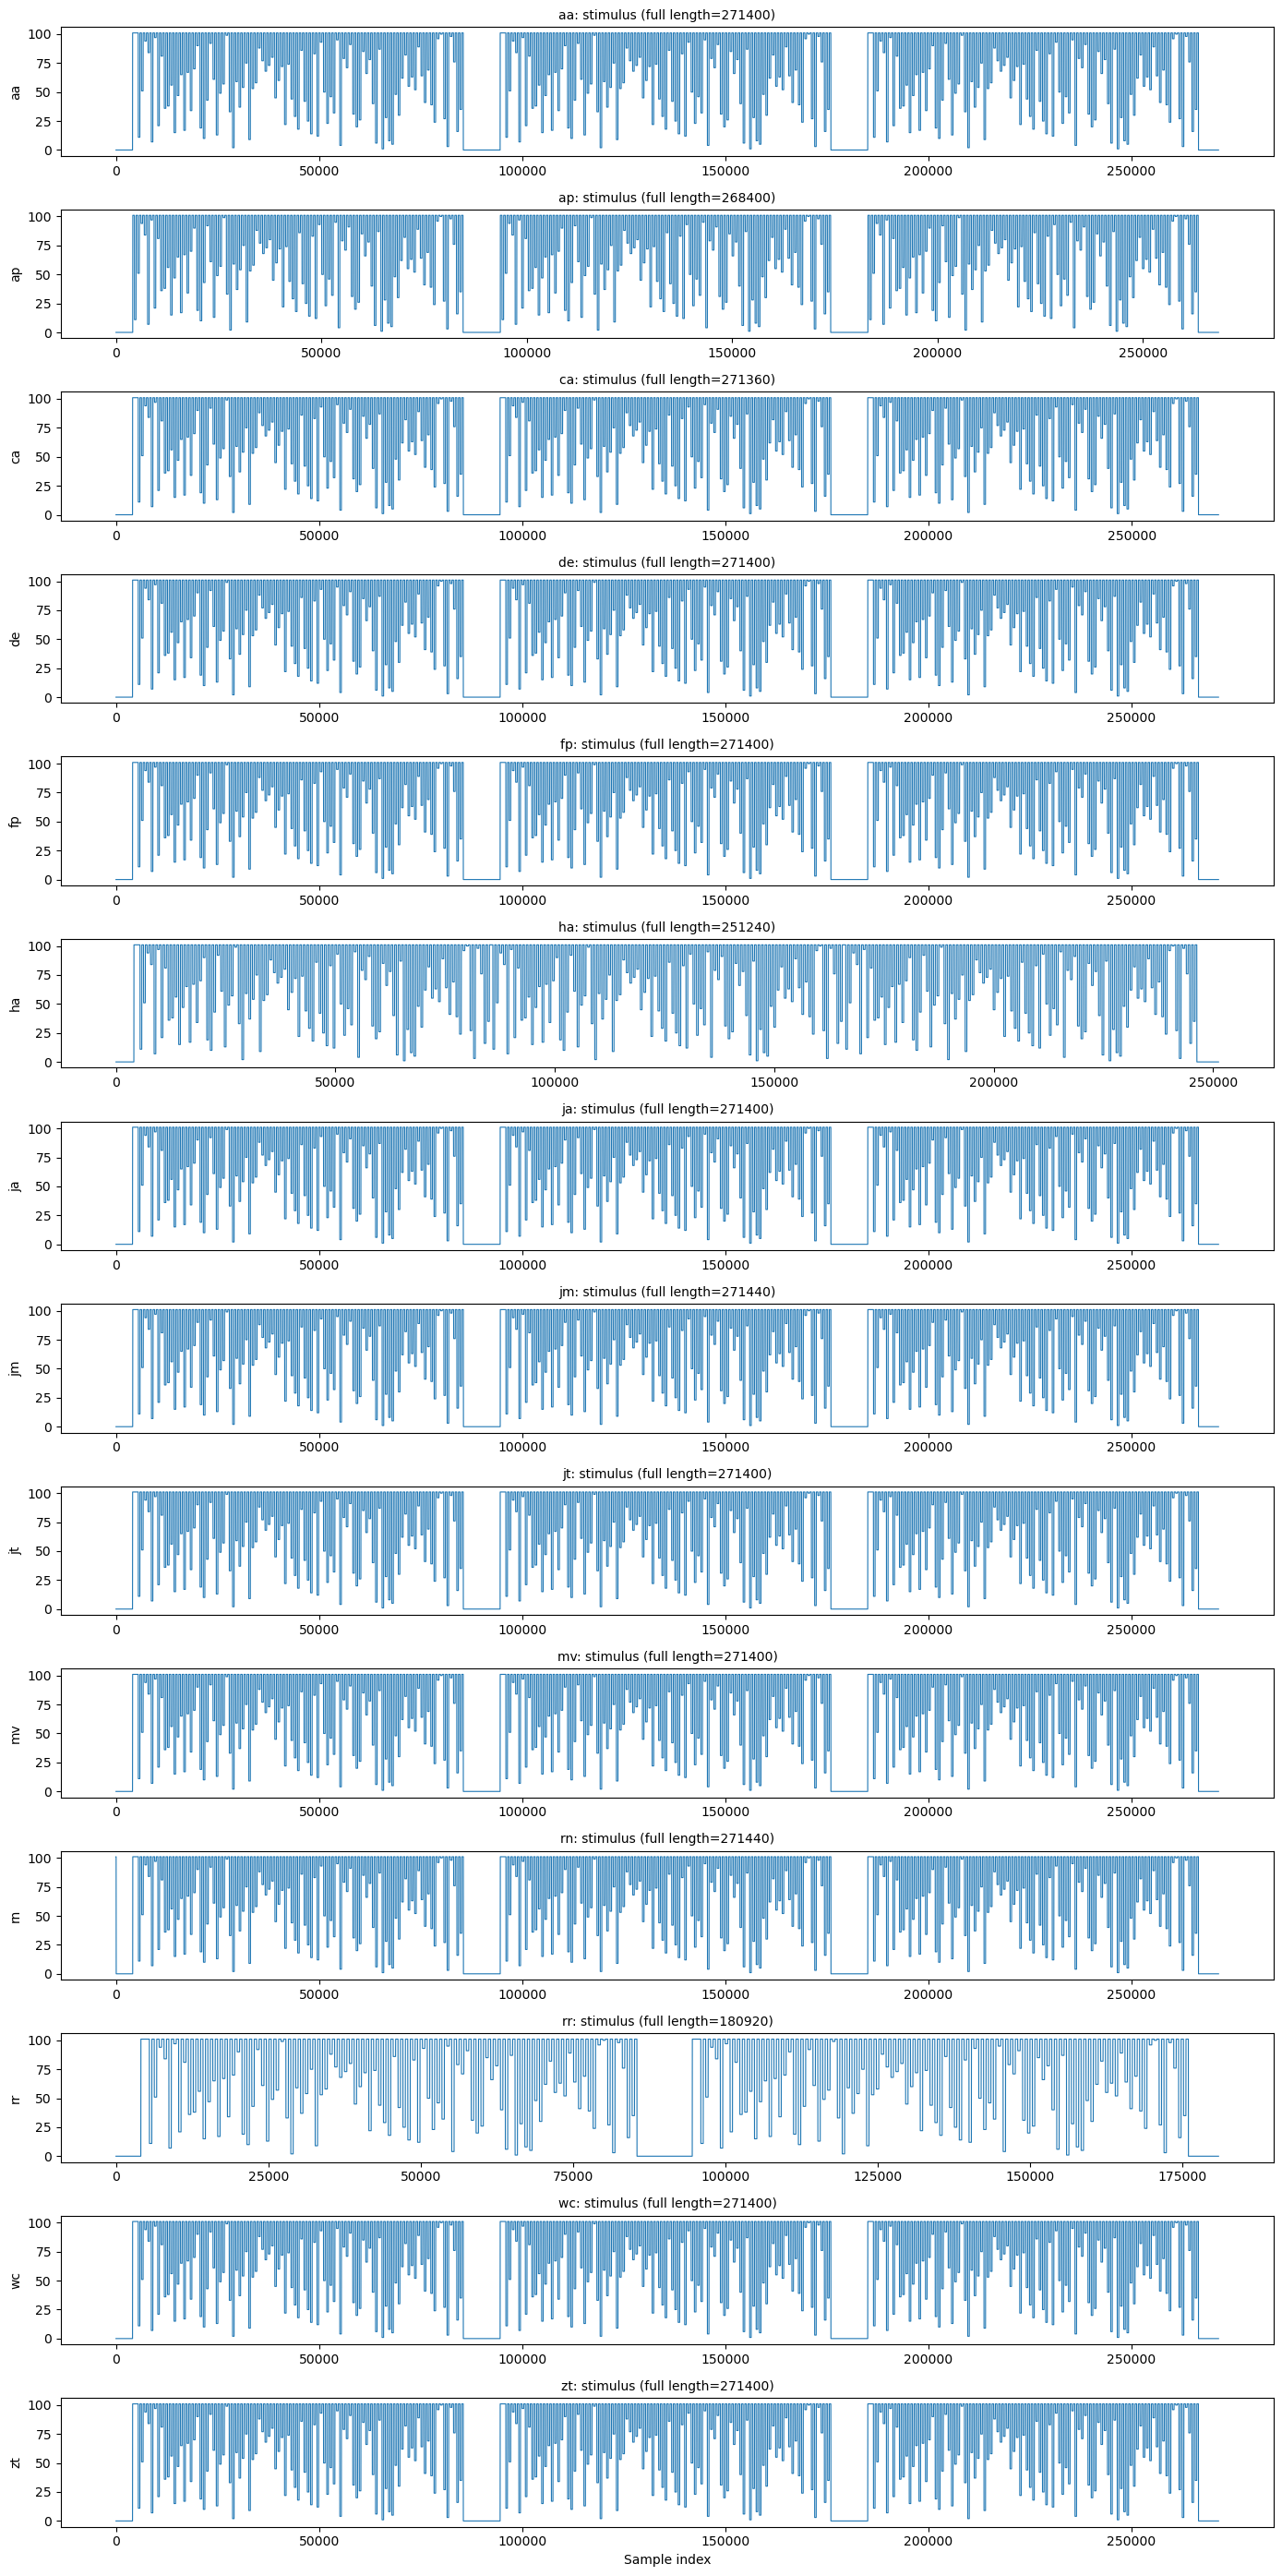

In [23]:
# Plot full stimulus trace for each subject
# (similar to plt.plot(stimulus[3000:10000]) but over the full recording)
import matplotlib.pyplot as plt

pids = sorted(stim_by_subject.keys())
if not pids:
    raise RuntimeError('No stim vectors loaded.')

fig, axes = plt.subplots(len(pids), 1, figsize=(14, 2.0 * len(pids)), sharex=False)
if len(pids) == 1:
    axes = [axes]

for ax, pid in zip(axes, pids):
    stim = stim_by_subject[pid]
    ax.plot(stim, linewidth=0.8)
    ax.set_ylabel(pid)
    ax.set_title(f'{pid}: stimulus (full length={len(stim)})', fontsize=10)

axes[-1].set_xlabel('Sample index')
plt.tight_layout()
plt.show()


## Clearer Event-Order View (By Event Index, Not Sample Index)

This compares subjects using the collapsed non-zero event sequence, which is the order check used above.


Reference: aa
Reference first 30 events (event IDs): [101, 11, 101, 51, 101, 94, 101, 84, 101, 7, 101, 97, 101, 21, 101, 81, 101, 36, 101, 38, 101, 56, 101, 15, 101, 47, 101, 65, 101, 17]

Detailed mismatch report:
  aa: events=601 | identical full sequence
  ap: events=601 | identical full sequence
  ca: events=601 | identical full sequence
  de: events=601 | identical full sequence
  fp: events=601 | identical full sequence
  ha: events=601 | identical full sequence
  ja: events=601 | identical full sequence
  jm: events=601 | identical full sequence
  jt: events=601 | identical full sequence
  mv: events=601 | identical full sequence
  rn: events=601 | identical full sequence
  rr: events=401 | identical prefix of length 401 (subject shorter)
  wc: events=601 | identical full sequence
  zt: events=601 | identical full sequence


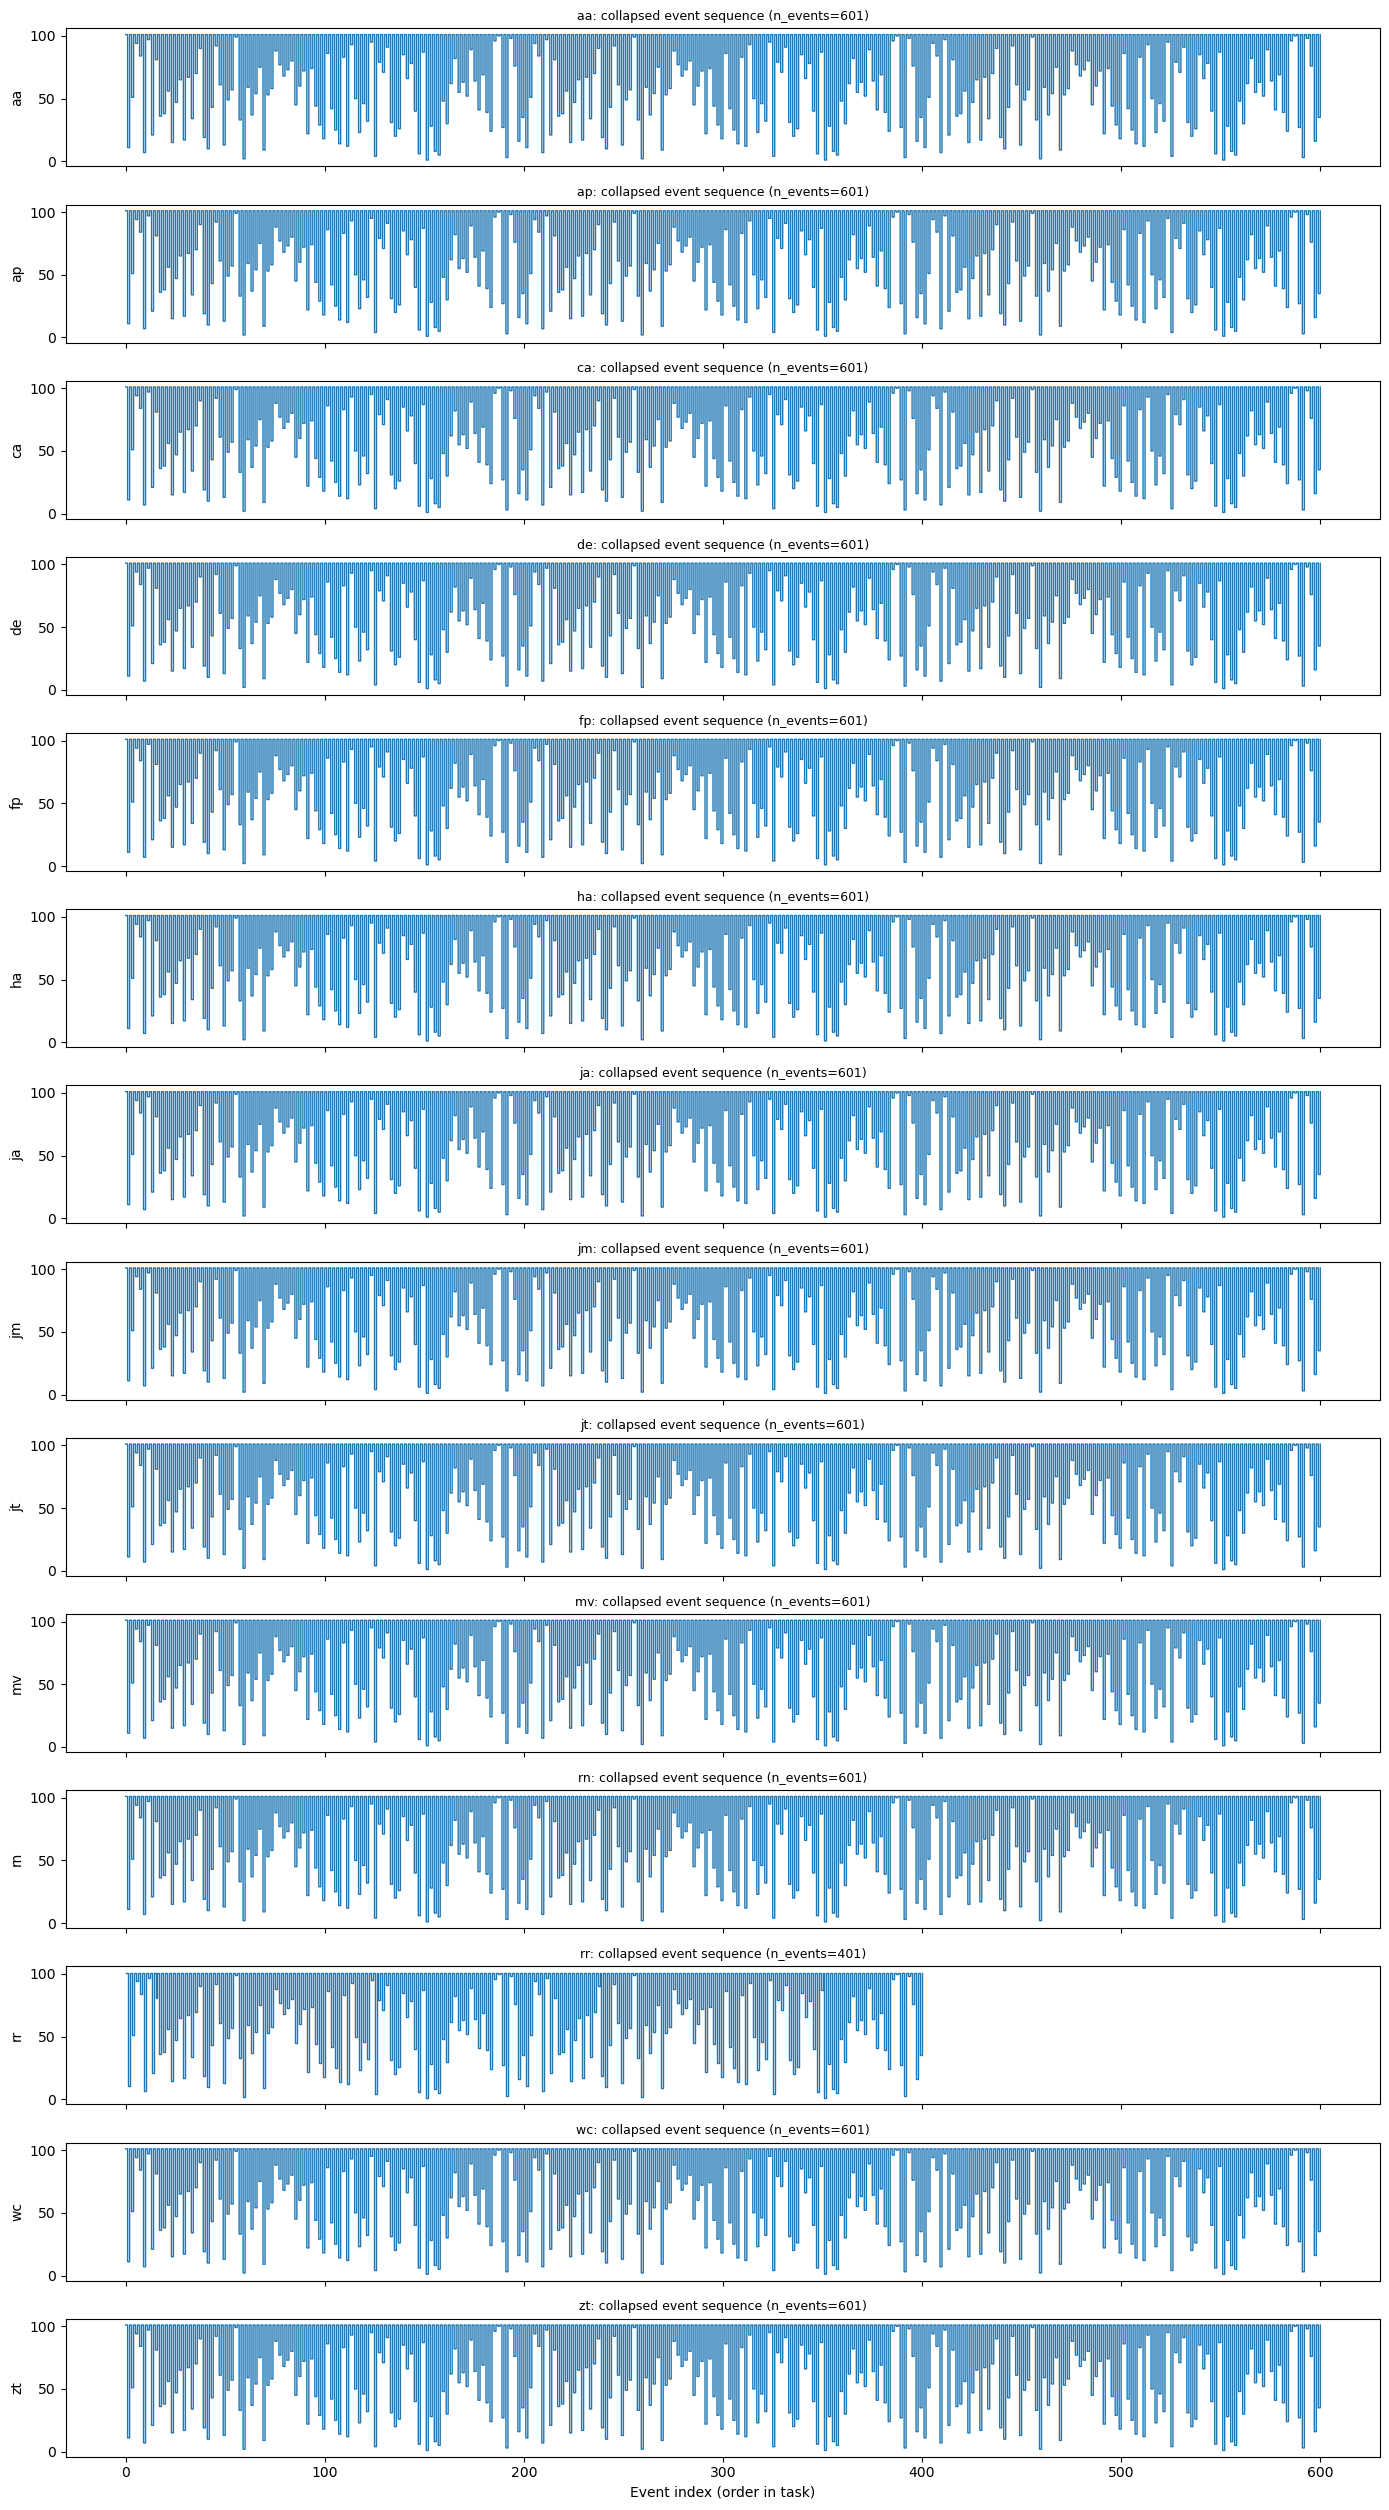

In [24]:
# Clearer event-order diagnostics and plot
# - Uses collapsed non-zero event sequence (event identity order)
# - Reports first mismatch index against reference
# - Plots event-id vs event-number for each subject

import numpy as np
import matplotlib.pyplot as plt

if 'aa' in stim_by_subject:
    ref_pid = 'aa'
else:
    ref_pid = sorted(stim_by_subject.keys())[0]

seq_by_subject = {pid: collapse_event_order(stim) for pid, stim in stim_by_subject.items()}
ref_seq = seq_by_subject[ref_pid]

print('Reference:', ref_pid)
print('Reference first 30 events (event IDs):', ref_seq[:30].astype(int).tolist())
print('')

print('Detailed mismatch report:')
for pid in sorted(seq_by_subject.keys()):
    seq = seq_by_subject[pid]
    m = min(len(seq), len(ref_seq))
    diff_idx = np.where(seq[:m] != ref_seq[:m])[0]

    if diff_idx.size == 0:
        if len(seq) == len(ref_seq):
            msg = 'identical full sequence'
        elif len(seq) < len(ref_seq):
            msg = f'identical prefix of length {len(seq)} (subject shorter)'
        else:
            msg = f'reference is prefix of length {len(ref_seq)} (subject longer)'
    else:
        k = int(diff_idx[0])
        msg = f'first mismatch at event #{k}: subject={int(seq[k])}, ref={int(ref_seq[k])}'

    print(f'  {pid}: events={len(seq)} | {msg}')

# Plot each collapsed sequence by event index
pids = sorted(seq_by_subject.keys())
fig, axes = plt.subplots(len(pids), 1, figsize=(14, 1.8 * len(pids)), sharex=True)
if len(pids) == 1:
    axes = [axes]

for ax, pid in zip(axes, pids):
    seq = seq_by_subject[pid]
    ax.step(np.arange(len(seq)), seq, where='post', linewidth=1.0)
    ax.set_ylabel(pid)
    ax.set_title(f'{pid}: collapsed event sequence (n_events={len(seq)})', fontsize=9)

axes[-1].set_xlabel('Event index (order in task)')
plt.tight_layout()
plt.show()
